# ***TASK 2:***

---



---



Processing: 1000
Processing: 40000
Processing: 80000
Processing: 200000
Processing: 1000000

Result Table:
   Tree Size  BFS Time  DFS Time
0       1000  0.000453  0.000211
1      40000  0.032121  0.023487
2      80000  0.149355  0.072551
3     200000  0.368452  0.119444
4    1000000  1.126746  0.030157


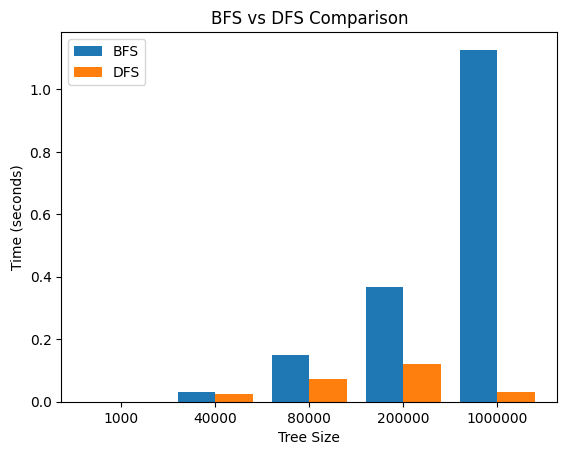

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# REQUIRED sizes
sizes = [1000, 40000, 80000, 200000, 1000000]

bfs_times = []
dfs_times = []

# build tree
def build_tree(values):
    tree = {}
    for i in range(len(values)):
        tree[values[i]] = []

        left = 2*i + 1
        right = 2*i + 2

        if left < len(values):
            tree[values[i]].append(values[left])
        if right < len(values):
            tree[values[i]].append(values[right])

    return tree

# BFS
def bfs(tree, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            for neighbor in tree[node]:
                queue.append(neighbor)

# DFS
def dfs(tree, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            for neighbor in tree[node]:
                stack.append(neighbor)

# main loop
for size in sizes:
    print("Processing:", size)

    values = random.sample(range(size * 10), size)
    tree = build_tree(values)

    start = values[0]
    goal = values[len(values) - 220]   # REQUIRED

    # BFS timing
    t1 = time.time()
    bfs(tree, start, goal)
    t2 = time.time()
    bfs_times.append(t2 - t1)

    # DFS timing
    t1 = time.time()
    dfs(tree, start, goal)
    t2 = time.time()
    dfs_times.append(t2 - t1)

# DataFrame (REQUIRED)
df = pd.DataFrame({
    "Tree Size": sizes,
    "BFS Time": bfs_times,
    "DFS Time": dfs_times
})

print("\nResult Table:")
print(df)

# Bar Chart (REQUIRED)
x = range(len(sizes))

plt.bar(x, bfs_times, width=0.4, label="BFS")
plt.bar([i + 0.4 for i in x], dfs_times, width=0.4, label="DFS")

plt.xticks([i + 0.2 for i in x], sizes)
plt.xlabel("Tree Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Comparison")
plt.legend()

plt.show()

# ***TASK 3:***

---



---



In [2]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

# run
result = bfs_shortest_path("Islamabad", "Karachi")
print("Shortest Path:", " → ".join(result))

Shortest Path: Islamabad → Rawalpindi → Quetta → Karachi
